In [397]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [398]:
X_train = pd.read_csv("../data/preprocessed/X_train_pca.csv")
X_test = pd.read_csv("../data/preprocessed/X_test_pca.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2496, 80)
X_test shape: (278, 80)
y_train shape: (2496,)
y_test shape: (278,)


In [399]:
import os

print(os.getcwd())

c:\G1436_ML_Voltage\notebooks


In [400]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("../data/preprocessed/X_train_pca.csv")
X_test = pd.read_csv("../data/preprocessed/X_test_pca.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2496, 80)
X_test shape: (278, 80)
y_train shape: (2496,)
y_test shape: (278,)


In [401]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("SVR model created successfully")

SVR model created successfully


In [402]:
svr_model.fit(X_train, y_train)

print("SVR training completed")

SVR training completed


In [403]:
y_pred_svr = svr_model.predict(X_test)

print("SVR prediction completed")
print(y_pred_svr[:10])

SVR prediction completed
[3.77997874 3.23847289 4.10256748 3.59423613 4.65286386 3.90277469
 4.57601261 3.65454552 3.35939266 4.15154248]


In [404]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE
mae_svr = mean_absolute_error(y_test, y_pred_svr)

# RMSE
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

# R²
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Performance")
print("----------------")
print("MAE  :", mae_svr)
print("RMSE :", rmse_svr)
print("R²   :", r2_svr)

SVR Performance
----------------
MAE  : 0.6387977037753678
RMSE : 1.0294705360974312
R²   : 0.5356111720002864


In [405]:
import joblib

joblib.dump(svr_model, "../models/svr_model.pkl")

print("SVR model saved successfully")

SVR model saved successfully


In [406]:
svr_results = pd.DataFrame({
    "Model": ["SVR"],
    "MAE": [mae_svr],
    "RMSE": [rmse_svr],
    "R2": [r2_svr]
})

svr_results.to_csv(
    "../results/svr_results.csv",
    index=False
)

print(svr_results)

  Model       MAE      RMSE        R2
0   SVR  0.638798  1.029471  0.535611


In [407]:
import pandas as pd

X_train_scaled = pd.read_csv("../data/preprocessed/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../data/preprocessed/X_test_scaled.csv")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (2496, 117)
X_test_scaled shape: (278, 117)


In [408]:
from sklearn.decomposition import PCA

pca_60 = PCA(n_components=60)

X_train_pca60 = pca_60.fit_transform(X_train_scaled)
X_test_pca60 = pca_60.transform(X_test_scaled)

print("X_train_pca60 shape:", X_train_pca60.shape)
print("X_test_pca60 shape:", X_test_pca60.shape)

X_train_pca60 shape: (2496, 60)
X_test_pca60 shape: (278, 60)


In [ ]:
from sklearn.svm import SVR

svr_pca60 = SVR(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svr_pca60.fit(X_train_pca60, y_train)

y_pred_pca60 = svr_pca60.predict(X_test_pca60)

print("SVR with 60 PCA components trained successfully!")

SVR with 60 PCA components trained successfully!


In [410]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_pca60 = mean_absolute_error(y_test, y_pred_pca60)
rmse_pca60 = np.sqrt(mean_squared_error(y_test, y_pred_pca60))
r2_pca60 = r2_score(y_test, y_pred_pca60)

print("SVR with 60 PCA Components")
print("MAE :", mae_pca60)
print("RMSE:", rmse_pca60)
print("R²  :", r2_pca60)

SVR with 60 PCA Components
MAE : 0.6491418241222038
RMSE: 1.0364696664091018
R²  : 0.5292751635664015


In [411]:
from sklearn.decomposition import PCA

pca_100 = PCA(n_components=100)

X_train_pca100 = pca_100.fit_transform(X_train_scaled)
X_test_pca100 = pca_100.transform(X_test_scaled)

print("X_train_pca100 shape:", X_train_pca100.shape)
print("X_test_pca100 shape:", X_test_pca100.shape)

X_train_pca100 shape: (2496, 100)
X_test_pca100 shape: (278, 100)


In [412]:
from sklearn.svm import SVR

svr_pca100 = SVR(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svr_pca100.fit(X_train_pca100, y_train)

y_pred_pca100 = svr_pca100.predict(X_test_pca100)

print("SVR with 100 PCA components trained successfully!")

SVR with 100 PCA components trained successfully!


In [413]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_pca100 = mean_absolute_error(y_test, y_pred_pca100)
rmse_pca100 = np.sqrt(mean_squared_error(y_test, y_pred_pca100))
r2_pca100 = r2_score(y_test, y_pred_pca100)

print("SVR with 100 PCA Components")
print("MAE :", mae_pca100)
print("RMSE:", rmse_pca100)
print("R²  :", r2_pca100)

SVR with 100 PCA Components
MAE : 0.629295313041713
RMSE: 1.023603236000794
R²  : 0.5408895048967657


In [414]:
from sklearn.decomposition import PCA

pca_110 = PCA(n_components=110)

X_train_pca110 = pca_110.fit_transform(X_train_scaled)
X_test_pca110 = pca_110.transform(X_test_scaled)

print("X_train_pca110 shape:", X_train_pca110.shape)
print("X_test_pca110 shape:", X_test_pca110.shape)

X_train_pca110 shape: (2496, 110)
X_test_pca110 shape: (278, 110)


In [415]:
from sklearn.svm import SVR

svr_pca110 = SVR(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svr_pca110.fit(X_train_pca110, y_train)

y_pred_pca110 = svr_pca110.predict(X_test_pca110)

print("SVR with 110 PCA components trained successfully!")

SVR with 110 PCA components trained successfully!


In [416]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_pca110 = mean_absolute_error(y_test, y_pred_pca110)
rmse_pca110 = np.sqrt(mean_squared_error(y_test, y_pred_pca110))
r2_pca110 = r2_score(y_test, y_pred_pca110)

print("SVR with 110 PCA Components")
print("MAE :", mae_pca110)
print("RMSE:", rmse_pca110)
print("R²  :", r2_pca110)

SVR with 110 PCA Components
MAE : 0.6287431061875323
RMSE: 1.02339237878187
R²  : 0.541078634410847


In [417]:
from sklearn.svm import SVR

svr_no_pca = SVR(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svr_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svr_no_pca.predict(X_test_scaled)

print("SVR without PCA trained successfully!")

SVR without PCA trained successfully!


In [418]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_no_pca = mean_absolute_error(y_test, y_pred_no_pca)
rmse_no_pca = np.sqrt(mean_squared_error(y_test, y_pred_no_pca))
r2_no_pca = r2_score(y_test, y_pred_no_pca)

print("SVR without PCA")
print("MAE :", mae_no_pca)
print("RMSE:", rmse_no_pca)
print("R²  :", r2_no_pca)

SVR without PCA
MAE : 0.6287431061875436
RMSE: 1.0233923787818608
R²  : 0.5410786344108551


In [436]:
from sklearn.svm import SVR

svr_c6 = SVR(
    kernel="rbf",
    C=6,
    gamma="scale"
)

svr_c6.fit(X_train_scaled, y_train)

y_pred_c6 = svr_c6.predict(X_test_scaled)

print("SVR with C=6, gamma=scale trained successfully!")

SVR with C=6, gamma=scale trained successfully!


In [437]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_c6 = mean_absolute_error(y_test, y_pred_c6)
rmse_c6 = np.sqrt(mean_squared_error(y_test, y_pred_c6))
r2_c6 = r2_score(y_test, y_pred_c6)

print("SVR with C=6, gamma=scale")
print("MAE :", mae_c6)
print("RMSE:", rmse_c6)
print("R²  :", r2_c6)

SVR with C=6, gamma=scale
MAE : 0.6267926561413212
RMSE: 1.0177958596349919
R²  : 0.5460842209195753


In [448]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Calculate feature importance using Mutual Information
mi_scores = mutual_info_regression(
    X_train,
    y_train,
    random_state=42
)

# Create a table of feature scores
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
})

# Sort from most important to least important
feature_scores = feature_scores.sort_values(
    by="MI_Score",
    ascending=False
)

print("Top 20 features:")
print(feature_scores.head(20))

Top 20 features:
   Feature  MI_Score
0      PC1  0.266652
1      PC2  0.262154
33    PC34  0.190089
30    PC31  0.181686
25    PC26  0.162996
35    PC36  0.150128
13    PC14  0.147353
44    PC45  0.141807
45    PC46  0.139018
19    PC20  0.138320
55    PC56  0.135969
51    PC52  0.135196
9     PC10  0.133165
28    PC29  0.132464
32    PC33  0.132446
40    PC41  0.131465
47    PC48  0.131373
15    PC16  0.128841
53    PC54  0.128114
39    PC40  0.125526


In [449]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Use the original scaled features, NOT PCA features
mi_scores_original = mutual_info_regression(
    X_train_scaled,
    y_train,
    random_state=42
)

# Create feature ranking
feature_scores_original = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "MI_Score": mi_scores_original
})

# Sort from highest to lowest
feature_scores_original = feature_scores_original.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

print("Top 20 original features:")
print(feature_scores_original.head(20))

Top 20 original features:
                   Feature  MI_Score
0     mendeleev_number_std  0.369687
1    mendeleev_number_mean  0.367288
2   electronegativity_mean  0.361462
3        atomic_radius_std  0.326872
4       atomic_radius_mean  0.324801
5    electronegativity_std  0.312098
6         atomic_mass_mean  0.294825
7       atomic_number_mean  0.274035
8     mendeleev_number_min  0.238120
9          atomic_mass_std  0.233998
10   electronegativity_min  0.232048
11              fraction_O  0.218653
12       atomic_number_std  0.211890
13           oxidation_std  0.205176
14           capacity_grav  0.198269
15       atomic_number_max  0.195639
16         atomic_mass_max  0.193754
17            capacity_vol  0.192917
18          lattice_volume  0.168805
19             total_atoms  0.166211


In [454]:
top_70_features = feature_scores_original.head(70)["Feature"].tolist()

X_train_top70 = X_train_scaled[top_70_features]
X_test_top70 = X_test_scaled[top_70_features]

svr_top70 = SVR(
    kernel="rbf",
    C=6,
    gamma="scale"
)

svr_top70.fit(X_train_top70, y_train)

y_pred_top70 = svr_top70.predict(X_test_top70)

mae_top70 = mean_absolute_error(y_test, y_pred_top70)
rmse_top70 = np.sqrt(mean_squared_error(y_test, y_pred_top70))
r2_top70 = r2_score(y_test, y_pred_top70)

print("SVR with Top 70 Features")
print("------------------------")
print(f"MAE  = {mae_top70:.6f} V")
print(f"RMSE = {rmse_top70:.6f} V")
print(f"R²   = {r2_top70:.6f}")

SVR with Top 70 Features
------------------------
MAE  = 0.604176 V
RMSE = 1.007837 V
R²   = 0.554923


In [455]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# SVR model
svr_60 = SVR(kernel="rbf")

# Parameters to test
param_grid_60 = {
    "C": [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20],
    "gamma": ["scale", 0.001, 0.002, 0.005, 0.01, 0.02, 0.03]
}

# Grid Search
grid_search_60 = GridSearchCV(
    estimator=svr_60,
    param_grid=param_grid_60,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# IMPORTANT: use the 60 selected features
grid_search_60.fit(X_train_top60, y_train)

print("Best Parameters:")
print(grid_search_60.best_params_)

print("\nBest CV RMSE:")
print((-grid_search_60.best_score_) ** 0.5)

Fitting 5 folds for each of 77 candidates, totalling 385 fits
Best Parameters:
{'C': 7, 'gamma': 0.005}

Best CV RMSE:
1.2197014518518272


In [456]:
# Get the best model from GridSearchCV
best_svr_60 = grid_search_60.best_estimator_

# Predict on test data
y_pred_best_60 = best_svr_60.predict(X_test_top60)

# Calculate metrics
mae_best_60 = mean_absolute_error(y_test, y_pred_best_60)
rmse_best_60 = np.sqrt(mean_squared_error(y_test, y_pred_best_60))
r2_best_60 = r2_score(y_test, y_pred_best_60)

print("Improved SVR - 60 Features")
print("--------------------------")
print(f"MAE  = {mae_best_60:.6f} V")
print(f"RMSE = {rmse_best_60:.6f} V")
print(f"R²   = {r2_best_60:.6f}")

Improved SVR - 60 Features
--------------------------
MAE  = 0.612970 V
RMSE = 0.976986 V
R²   = 0.581755


In [457]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# SVR model
svr_fine = SVR(kernel="rbf")

# Fine search around the current best
param_grid_fine = {
    "C": [6, 6.5, 7, 7.5, 8],
    "gamma": [0.003, 0.004, 0.005, 0.006, 0.007]
}

grid_fine = GridSearchCV(
    estimator=svr_fine,
    param_grid=param_grid_fine,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Use the 60 selected features
grid_fine.fit(X_train_top60, y_train)

print("Best Parameters:")
print(grid_fine.best_params_)

print("\nBest CV RMSE:")
print((-grid_fine.best_score_) ** 0.5)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters:
{'C': 7, 'gamma': 0.005}

Best CV RMSE:
1.2197014518518272


In [458]:
# Get the best fine-tuned SVR
final_svr_60 = grid_fine.best_estimator_

# Predict on the test set
y_pred_final = final_svr_60.predict(X_test_top60)

# Calculate metrics
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("FINAL SVR - 60 Selected Features")
print("--------------------------------")
print(f"MAE  = {mae_final:.6f} V")
print(f"RMSE = {rmse_final:.6f} V")
print(f"R²   = {r2_final:.6f}")

FINAL SVR - 60 Selected Features
--------------------------------
MAE  = 0.612970 V
RMSE = 0.976986 V
R²   = 0.581755


In [459]:
from sklearn.svm import SVR

epsilon_values = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]

epsilon_results = []

for eps in epsilon_values:

    model = SVR(
        kernel="rbf",
        C=7,
        gamma=0.005,
        epsilon=eps
    )

    model.fit(X_train_top60, y_train)

    pred = model.predict(X_test_top60)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    epsilon_results.append({
        "Epsilon": eps,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

epsilon_results_df = pd.DataFrame(epsilon_results)

print(epsilon_results_df)

   Epsilon       MAE      RMSE        R2
0     0.01  0.611320  0.981168  0.578167
1     0.05  0.611496  0.980138  0.579052
2     0.10  0.612970  0.976986  0.581755
3     0.20  0.616705  0.975478  0.583045
4     0.30  0.623478  0.981506  0.577876
5     0.50  0.640392  0.982749  0.576807


In [460]:
from sklearn.svm import SVR

epsilon_values_fine = [0.15, 0.18, 0.20, 0.22, 0.25]

epsilon_fine_results = []

for eps in epsilon_values_fine:

    model = SVR(
        kernel="rbf",
        C=7,
        gamma=0.005,
        epsilon=eps
    )

    model.fit(X_train_top60, y_train)

    pred = model.predict(X_test_top60)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    epsilon_fine_results.append({
        "Epsilon": eps,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

epsilon_fine_df = pd.DataFrame(epsilon_fine_results)

print(epsilon_fine_df)

   Epsilon       MAE      RMSE        R2
0     0.15  0.615196  0.976059  0.582549
1     0.18  0.616486  0.975618  0.582926
2     0.20  0.616705  0.975478  0.583045
3     0.22  0.617358  0.976223  0.582408
4     0.25  0.619543  0.980256  0.578951


In [461]:
import pandas as pd
import numpy as np

X_train_raw = pd.read_csv("../data/preprocessed/X_train.csv")
X_test_raw = pd.read_csv("../data/preprocessed/X_test.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").squeeze()

print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2496, 117)
X_test : (278, 117)
y_train: (2496,)
y_test : (278,)


In [462]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_train_standard = pd.DataFrame(
    standard_scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns
)

X_test_standard = pd.DataFrame(
    standard_scaler.transform(X_test_raw),
    columns=X_test_raw.columns
)

print("StandardScaler completed")
print("X_train:", X_train_standard.shape)
print("X_test :", X_test_standard.shape)

StandardScaler completed
X_train: (2496, 117)
X_test : (278, 117)


In [464]:
# Select the same 60 features used in our best SVR model

top60_features = feature_scores_original["Feature"].head(60).tolist()

X_train_standard_top60 = X_train_standard[top60_features]
X_test_standard_top60 = X_test_standard[top60_features]

print("Selected features:", len(top60_features))
print("X_train:", X_train_standard_top60.shape)
print("X_test :", X_test_standard_top60.shape)

Selected features: 60
X_train: (2496, 60)
X_test : (278, 60)


In [465]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_standard = SVR(
    kernel="rbf",
    C=7,
    gamma=0.005,
    epsilon=0.20
)

svr_standard.fit(X_train_standard_top60, y_train)

y_pred_standard = svr_standard.predict(X_test_standard_top60)

mae_standard = mean_absolute_error(y_test, y_pred_standard)
rmse_standard = np.sqrt(mean_squared_error(y_test, y_pred_standard))
r2_standard = r2_score(y_test, y_pred_standard)

print("StandardScaler + SVR")
print("--------------------")
print("MAE  :", mae_standard)
print("RMSE :", rmse_standard)
print("R²   :", r2_standard)

StandardScaler + SVR
--------------------
MAE  : 0.6167053955421337
RMSE : 0.9754780727479216
R²   : 0.5830452329914365


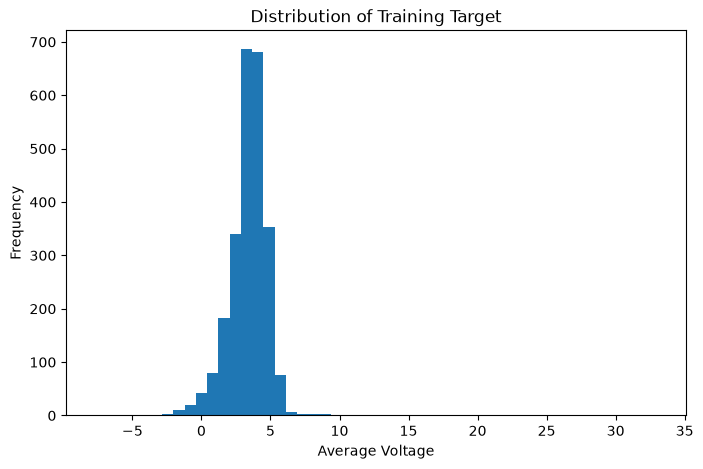

Target statistics:
count    2496.000000
mean        3.411800
std         1.534443
min        -7.754751
25%         2.773464
50%         3.526401
75%         4.203539
max        33.065771
Name: average_voltage, dtype: float64


In [470]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=50)
plt.xlabel("Average Voltage")
plt.ylabel("Frequency")
plt.title("Distribution of Training Target")
plt.show()

print("Target statistics:")
print(y_train.describe())

In [471]:
from sklearn.preprocessing import PowerTransformer
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Yeo-Johnson transformer
target_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

# Transform training target
y_train_transformed = target_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

# Create SVR
svr_yj = SVR(
    kernel="rbf",
    C=7,
    gamma=0.005,
    epsilon=0.20
)

# Train on transformed target
svr_yj.fit(
    X_train_standard_top60,
    y_train_transformed
)

# Predict transformed target
y_pred_transformed = svr_yj.predict(X_test_standard_top60)

# Convert predictions back to original voltage scale
y_pred_yj = target_transformer.inverse_transform(
    y_pred_transformed.reshape(-1, 1)
).ravel()

# Evaluate on original voltage scale
mae_yj = mean_absolute_error(y_test, y_pred_yj)
rmse_yj = np.sqrt(mean_squared_error(y_test, y_pred_yj))
r2_yj = r2_score(y_test, y_pred_yj)

print("SVR + Yeo-Johnson Target Transformation")
print("-----------------------------------------")
print("MAE  :", mae_yj)
print("RMSE :", rmse_yj)
print("R²   :", r2_yj)

SVR + Yeo-Johnson Target Transformation
-----------------------------------------
MAE  : 0.608777664932915
RMSE : 0.9608779616067443
R²   : 0.5954330646616122


In [472]:
from sklearn.preprocessing import PowerTransformer

target_transformer_cv = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

y_train_yj = target_transformer_cv.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

print("Yeo-Johnson transformation completed")
print("Original target shape   :", y_train.shape)
print("Transformed target shape:", y_train_yj.shape)

Yeo-Johnson transformation completed
Original target shape   : (2496,)
Transformed target shape: (2496,)


In [473]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_cv = SVR(kernel="rbf")

param_grid_yj = {
    "C": [3, 5, 7, 10, 15],
    "gamma": [0.003, 0.005, 0.007, 0.01],
    "epsilon": [0.10, 0.15, 0.20, 0.25]
}

grid_yj = GridSearchCV(
    estimator=svr_cv,
    param_grid=param_grid_yj,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_yj.fit(
    X_train_standard_top60,
    y_train_yj
)

print("Best parameters:")
print(grid_yj.best_params_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_yj.best_score_))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters:
{'C': 5, 'epsilon': 0.1, 'gamma': 0.005}

Best CV RMSE:
0.7918218630879794


In [474]:
# Train the CV-selected model

best_svr_yj = SVR(
    kernel="rbf",
    C=5,
    gamma=0.005,
    epsilon=0.10
)

best_svr_yj.fit(
    X_train_standard_top60,
    y_train_yj
)

# Predict on the test set
y_pred_yj_cv = best_svr_yj.predict(
    X_test_standard_top60
)

# Convert predictions back to original voltage scale
y_pred_final = target_transformer_cv.inverse_transform(
    y_pred_yj_cv.reshape(-1, 1)
).ravel()

# Evaluate in original voltage units
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("Final CV-selected SVR + Yeo-Johnson")
print("-----------------------------------")
print("C      :", 5)
print("Gamma  :", 0.005)
print("Epsilon:", 0.10)
print()
print("MAE  :", mae_final)
print("RMSE :", rmse_final)
print("R²   :", r2_final)

Final CV-selected SVR + Yeo-Johnson
-----------------------------------
C      : 5
Gamma  : 0.005
Epsilon: 0.1

MAE  : 0.6129511378310647
RMSE : 0.972931764597702
R²   : 0.5852191611807577


In [475]:
feature_counts = [10, 20, 30, 40, 50, 60,
                  70, 80, 90, 100, 110, 117]

feature_count_results = []

for n_features in feature_counts:

    selected_features = feature_scores_original["Feature"].head(n_features).tolist()

    Xtr = X_train_standard[selected_features]
    Xte = X_test_standard[selected_features]

    model = SVR(
        kernel="rbf",
        C=5,
        gamma=0.005,
        epsilon=0.10
    )

    model.fit(Xtr, y_train_yj)

    pred_transformed = model.predict(Xte)

    # Convert predictions back to voltage
    pred = target_transformer_cv.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    feature_count_results.append({
        "Features": n_features,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

feature_count_df = pd.DataFrame(feature_count_results)

print(feature_count_df.to_string(index=False))

print("\nBest R²:")
print(
    feature_count_df.loc[
        feature_count_df["R2"].idxmax()
    ]
)

 Features      MAE     RMSE       R2
       10 0.738466 1.087847 0.481452
       20 0.685938 1.047718 0.519003
       30 0.667556 1.043504 0.522864
       40 0.656231 1.024725 0.539883
       50 0.624063 0.992353 0.568494
       60 0.612951 0.972932 0.585219
       70 0.606940 0.975573 0.582964
       80 0.607786 0.983023 0.576571
       90 0.609657 0.978056 0.580839
      100 0.612954 0.982815 0.576749
      110 0.622378 0.989530 0.570946
      117 0.630727 1.008345 0.554475

Best R²:
Features    60.000000
MAE          0.612951
RMSE         0.972932
R2           0.585219
Name: 5, dtype: float64


In [476]:
# Step 1: Prepare data for advanced SVR tuning

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Use the already selected top 60 features
X_train_svr = X_train_standard_top60.copy()
X_test_svr = X_test_standard_top60.copy()

# Yeo-Johnson transformation for the target
target_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

y_train_svr = target_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

print("X_train shape:", X_train_svr.shape)
print("X_test shape:", X_test_svr.shape)
print("y_train shape:", y_train_svr.shape)

X_train shape: (2496, 60)
X_test shape: (278, 60)
y_train shape: (2496,)


In [7]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


In [10]:
# Rebuild SVR data from saved files

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_regression

# Load original training and test data
X_train_raw = pd.read_csv("../data/preprocessed/X_train.csv")
X_test_raw = pd.read_csv("../data/preprocessed/X_test.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").squeeze()

# StandardScaler
standard_scaler = StandardScaler()

X_train_standard = pd.DataFrame(
    standard_scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns
)

X_test_standard = pd.DataFrame(
    standard_scaler.transform(X_test_raw),
    columns=X_test_raw.columns
)

# Mutual Information feature selection
mi_scores = mutual_info_regression(
    X_train_standard,
    y_train,
    random_state=42
)

feature_scores = pd.DataFrame({
    "Feature": X_train_standard.columns,
    "MI_Score": mi_scores
}).sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

# Select top 60 features
top60_features = feature_scores["Feature"].head(60).tolist()

X_train_svr = X_train_standard[top60_features].copy()
X_test_svr = X_test_standard[top60_features].copy()

# Yeo-Johnson transformation of target
target_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

y_train_svr = target_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

print("X_train_svr:", X_train_svr.shape)
print("X_test_svr :", X_test_svr.shape)
print("y_train_svr:", y_train_svr.shape)
print("Top 5 features:")
print(top60_features[:5])

X_train_svr: (2496, 60)
X_test_svr : (278, 60)
y_train_svr: (2496,)
Top 5 features:
['mendeleev_number_std', 'mendeleev_number_mean', 'electronegativity_mean', 'atomic_radius_std', 'atomic_radius_mean']


In [12]:
# Faster SVR hyperparameter search

param_grid_fast = {
    "C": [3, 5, 7, 10],
    "gamma": [0.003, 0.005, 0.007, 0.01],
    "epsilon": [0.10, 0.15, 0.20]
}

svr_fast = SVR(kernel="rbf")

grid_fast = GridSearchCV(
    estimator=svr_fast,
    param_grid=param_grid_fast,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_fast.fit(X_train_svr, y_train_svr)

print("\nBest parameters:")
print(grid_fast.best_params_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_fast.best_score_))

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best parameters:
{'C': 3, 'epsilon': 0.1, 'gamma': 0.01}

Best CV RMSE:
0.7925092435119917


In [13]:
# Step 3: Evaluate the best SVR on the test set

best_svr = SVR(
    kernel="rbf",
    C=3,
    gamma=0.01,
    epsilon=0.10
)

# Train on the transformed training target
best_svr.fit(X_train_svr, y_train_svr)

# Predict transformed target
y_pred_transformed = best_svr.predict(X_test_svr)

# Convert predictions back to original voltage scale
y_pred = target_transformer.inverse_transform(
    y_pred_transformed.reshape(-1, 1)
).ravel()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("SVR Test Results")
print("----------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

SVR Test Results
----------------
MAE  : 0.5954145290313918
RMSE : 0.9688977275679488
R²   : 0.5886516165068416


In [14]:
# Step 4: Targeted SVR hyperparameter search

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_targeted = {
    "C": [2, 2.5, 3, 3.5, 4, 5],
    
    "gamma": [0.007, 0.008, 0.009, 0.010, 0.012, 0.015],
    
    "epsilon": [0.05, 0.10, 0.15]
}

svr_targeted = SVR(kernel="rbf")

grid_targeted = GridSearchCV(
    estimator=svr_targeted,
    param_grid=param_grid_targeted,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_targeted.fit(X_train_svr, y_train_svr)

print("\nBest parameters:")
print(grid_targeted.best_params_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_targeted.best_score_))

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best parameters:
{'C': 3, 'epsilon': 0.1, 'gamma': 0.01}

Best CV RMSE:
0.7925092435119917


In [15]:
# Step 5: Final evaluation of the targeted-search SVR

best_svr_targeted = SVR(
    kernel="rbf",
    C=3,
    gamma=0.01,
    epsilon=0.10
)

# Train using the transformed training target
best_svr_targeted.fit(
    X_train_svr,
    y_train_svr
)

# Predict on test data
y_pred_transformed = best_svr_targeted.predict(X_test_svr)

# Convert predictions back to original voltage scale
y_pred_targeted = target_transformer.inverse_transform(
    y_pred_transformed.reshape(-1, 1)
).ravel()

# Calculate test metrics
mae_targeted = mean_absolute_error(y_test, y_pred_targeted)
rmse_targeted = np.sqrt(
    mean_squared_error(y_test, y_pred_targeted)
)
r2_targeted = r2_score(y_test, y_pred_targeted)

print("Targeted SVR Test Results")
print("-------------------------")
print("MAE  :", mae_targeted)
print("RMSE :", rmse_targeted)
print("R²   :", r2_targeted)

Targeted SVR Test Results
-------------------------
MAE  : 0.5954145290313918
RMSE : 0.9688977275679488
R²   : 0.5886516165068416


In [16]:
# Step 6A: Prepare data for SVR-based feature selection

from sklearn.feature_selection import RFE
from sklearn.svm import SVR

# Start with all 117 standardized features
X_train_rfe = X_train_standard.copy()
X_test_rfe = X_test_standard.copy()

print("Training data shape:", X_train_rfe.shape)
print("Test data shape    :", X_test_rfe.shape)

Training data shape: (2496, 117)
Test data shape    : (278, 117)


In [17]:
# Step 6B: SVR-based Recursive Feature Elimination (RFE)

from sklearn.feature_selection import RFE
from sklearn.svm import SVR

# SVR estimator used by RFE
svr_rfe = SVR(
    kernel="linear",
    C=1.0
)

# Select 60 features
rfe = RFE(
    estimator=svr_rfe,
    n_features_to_select=60,
    step=10,
    verbose=1
)

rfe.fit(X_train_rfe, y_train)

print("\nRFE completed!")
print("Selected features:", rfe.n_features_)

Fitting estimator with 117 features.
Fitting estimator with 107 features.
Fitting estimator with 97 features.
Fitting estimator with 87 features.
Fitting estimator with 77 features.
Fitting estimator with 67 features.

RFE completed!
Selected features: 60


In [18]:
# Step 6C: Create datasets using RFE-selected features

# Get the names of the selected features
rfe_features = X_train_rfe.columns[rfe.support_].tolist()

# Create training and test datasets
X_train_rfe60 = X_train_rfe[rfe_features]
X_test_rfe60 = X_test_rfe[rfe_features]

print("Number of selected features:", len(rfe_features))

print("\nFirst 10 selected features:")
print(rfe_features[:10])

print("\nTraining shape:", X_train_rfe60.shape)
print("Test shape    :", X_test_rfe60.shape)

Number of selected features: 60

First 10 selected features:
['atomic_mass_max', 'atomic_mass_mean', 'atomic_mass_min', 'atomic_mass_std', 'atomic_number_max', 'atomic_number_mean', 'atomic_number_min', 'atomic_number_std', 'atomic_radius_max', 'atomic_radius_mean']

Training shape: (2496, 60)
Test shape    : (278, 60)


In [19]:
# Step 6D: Evaluate RFE-selected features with the best RBF-SVR

svr_rfe_final = SVR(
    kernel="rbf",
    C=3,
    gamma=0.01,
    epsilon=0.10
)

# Train using RFE-selected features
svr_rfe_final.fit(
    X_train_rfe60,
    y_train_svr
)

# Predict on test data
y_pred_rfe_transformed = svr_rfe_final.predict(
    X_test_rfe60
)

# Convert predictions back to original voltage scale
y_pred_rfe = target_transformer.inverse_transform(
    y_pred_rfe_transformed.reshape(-1, 1)
).ravel()

# Calculate metrics
mae_rfe = mean_absolute_error(y_test, y_pred_rfe)
rmse_rfe = np.sqrt(mean_squared_error(y_test, y_pred_rfe))
r2_rfe = r2_score(y_test, y_pred_rfe)

print("RFE + SVR Test Results")
print("----------------------")
print("MAE  :", mae_rfe)
print("RMSE :", rmse_rfe)
print("R²   :", r2_rfe)

RFE + SVR Test Results
----------------------
MAE  : 0.6014378028468911
RMSE : 0.9755351779578705
R²   : 0.5829964138798431


In [20]:
# Step 7A: Create polynomial features for SVR

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_svr)
X_test_poly = poly.transform(X_test_svr)

print("Original features:", X_train_svr.shape[1])
print("Polynomial features:", X_train_poly.shape[1])
print("Training shape:", X_train_poly.shape)
print("Test shape:", X_test_poly.shape)

Original features: 60
Polynomial features: 1890
Training shape: (2496, 1890)
Test shape: (278, 1890)


In [21]:
# Step 7B: Scale polynomial features

from sklearn.preprocessing import StandardScaler

poly_scaler = StandardScaler()

X_train_poly_scaled = poly_scaler.fit_transform(X_train_poly)
X_test_poly_scaled = poly_scaler.transform(X_test_poly)

print("Scaled training shape:", X_train_poly_scaled.shape)
print("Scaled test shape    :", X_test_poly_scaled.shape)

Scaled training shape: (2496, 1890)
Scaled test shape    : (278, 1890)


In [22]:
# Step 7C: Train RBF-SVR using polynomial features

svr_poly = SVR(
    kernel="rbf",
    C=3,
    gamma=0.01,
    epsilon=0.10
)

print("Training SVR...")

svr_poly.fit(
    X_train_poly_scaled,
    y_train_svr
)

print("Training completed!")

# Predict on test data
y_pred_poly_transformed = svr_poly.predict(
    X_test_poly_scaled
)

# Convert predictions back to original voltage scale
y_pred_poly = target_transformer.inverse_transform(
    y_pred_poly_transformed.reshape(-1, 1)
).ravel()

# Calculate metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("\nPolynomial Features + SVR Results")
print("----------------------------------")
print("MAE  :", mae_poly)
print("RMSE :", rmse_poly)
print("R²   :", r2_poly)

Training SVR...
Training completed!

Polynomial Features + SVR Results
----------------------------------
MAE  : 0.8413972059782631
RMSE : 1.2841775624159313
R²   : 0.27738982033465753


In [23]:
# Step 8A: Inspect target voltage outliers

print("Target statistics")
print("-----------------")
print("Minimum :", y_train.min())
print("Maximum :", y_train.max())
print("Mean    :", y_train.mean())
print("Median  :", y_train.median())
print("Std     :", y_train.std())

print("\nExtreme-value counts")
print("--------------------")
print("Below 0 V   :", (y_train < 0).sum())
print("Above 5 V   :", (y_train > 5).sum())
print("Above 10 V  :", (y_train > 10).sum())
print("Above 20 V  :", (y_train > 20).sum())
print("Above 30 V  :", (y_train > 30).sum())

print("\nLargest 10 voltage values")
print("------------------------")
print(
    np.sort(y_train.to_numpy())[-10:]
)

print("\nSmallest 10 voltage values")
print("-------------------------")
print(
    np.sort(y_train.to_numpy())[:10]
)

Target statistics
-----------------
Minimum : -7.754751246666666
Maximum : 33.06577115833334
Mean    : 3.4117997430107505
Median  : 3.526401392083332
Std     : 1.5344426975785148

Extreme-value counts
--------------------
Below 0 V   : 61
Above 5 V   : 186
Above 10 V  : 6
Above 20 V  : 1
Above 30 V  : 1

Largest 10 voltage values
------------------------
[ 8.23436379  9.27962821  9.32297333  9.7391658  10.62304985 12.29607955
 13.08374888 15.54906313 16.12365561 33.06577116]

Smallest 10 voltage values
-------------------------
[-7.75475125 -6.93478878 -4.12174073 -2.23502282 -2.14591552 -2.01610527
 -1.9746546  -1.87617585 -1.86001512 -1.85190861]


In [24]:
# Step 8B: Detailed target distribution

ranges = {
    "Below 0 V": (y_train < 0),
    "0 to 2 V": ((y_train >= 0) & (y_train < 2)),
    "2 to 3 V": ((y_train >= 2) & (y_train < 3)),
    "3 to 4 V": ((y_train >= 3) & (y_train < 4)),
    "4 to 5 V": ((y_train >= 4) & (y_train < 5)),
    "5 to 10 V": ((y_train >= 5) & (y_train < 10)),
    "10 to 20 V": ((y_train >= 10) & (y_train < 20)),
    "20 to 30 V": ((y_train >= 20) & (y_train < 30)),
    "Above 30 V": (y_train >= 30)
}

for name, condition in ranges.items():
    print(f"{name:12s}: {condition.sum()}")

Below 0 V   : 61
0 to 2 V    : 260
2 to 3 V    : 451
3 to 4 V    : 937
4 to 5 V    : 601
5 to 10 V   : 180
10 to 20 V  : 5
20 to 30 V  : 0
Above 30 V  : 1


In [25]:
# Step 8C: Fine epsilon search for SVR

epsilon_values = [
    0.01,
    0.03,
    0.05,
    0.07,
    0.10,
    0.12,
    0.15,
    0.18,
    0.20,
    0.25,
    0.30
]

epsilon_results = []

for eps in epsilon_values:

    model = SVR(
        kernel="rbf",
        C=3,
        gamma=0.01,
        epsilon=eps
    )

    model.fit(
        X_train_svr,
        y_train_svr
    )

    pred_transformed = model.predict(X_test_svr)

    pred = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    epsilon_results.append({
        "epsilon": eps,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

epsilon_results_df = pd.DataFrame(epsilon_results)

print(epsilon_results_df.to_string(index=False))

print("\nBest by R²:")
print(
    epsilon_results_df.loc[
        epsilon_results_df["R2"].idxmax()
    ]
)

 epsilon      MAE     RMSE       R2
    0.01 0.594468 0.968616 0.588890
    0.03 0.592028 0.967453 0.589877
    0.05 0.593096 0.968983 0.588579
    0.07 0.594381 0.969887 0.587811
    0.10 0.595415 0.968898 0.588652
    0.12 0.596236 0.965963 0.591140
    0.15 0.599422 0.965659 0.591397
    0.18 0.604099 0.968121 0.589311
    0.20 0.609104 0.970306 0.587455
    0.25 0.615882 0.971451 0.586481
    0.30 0.625670 0.971484 0.586453

Best by R²:
epsilon    0.150000
MAE        0.599422
RMSE       0.965659
R2         0.591397
Name: 6, dtype: float64


In [26]:
epsilon_fine = [
    0.11,
    0.12,
    0.13,
    0.14,
    0.15,
    0.16,
    0.17,
    0.18,
    0.19
]

fine_results = []

for eps in epsilon_fine:

    model = SVR(
        kernel="rbf",
        C=3,
        gamma=0.01,
        epsilon=eps
    )

    model.fit(X_train_svr, y_train_svr)

    pred_transformed = model.predict(X_test_svr)

    pred = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    fine_results.append({
        "epsilon": eps,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

fine_results_df = pd.DataFrame(fine_results)

print(fine_results_df.to_string(index=False))

print("\nBest by R²:")
print(
    fine_results_df.loc[
        fine_results_df["R2"].idxmax()
    ]
)

 epsilon      MAE     RMSE       R2
    0.11 0.595556 0.967305 0.590003
    0.12 0.596236 0.965963 0.591140
    0.13 0.596920 0.965124 0.591850
    0.14 0.598038 0.965025 0.591933
    0.15 0.599422 0.965659 0.591397
    0.16 0.600828 0.966659 0.590550
    0.17 0.602146 0.967324 0.589987
    0.18 0.604099 0.968121 0.589311
    0.19 0.606745 0.969399 0.588226

Best by R²:
epsilon    0.140000
MAE        0.598038
RMSE       0.965025
R2         0.591933
Name: 3, dtype: float64


In [27]:
# Next experiment: fine C and gamma search
# Keep epsilon fixed at the current best value = 0.14

C_values = [2.0, 2.5, 3.0, 3.5, 4.0]
gamma_values = [0.007, 0.008, 0.009, 0.010, 0.011, 0.012, 0.014]

results_C_gamma = []

for C_value in C_values:
    for gamma_value in gamma_values:

        model = SVR(
            kernel="rbf",
            C=C_value,
            gamma=gamma_value,
            epsilon=0.14
        )

        model.fit(X_train_svr, y_train_svr)

        pred_transformed = model.predict(X_test_svr)

        pred = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        results_C_gamma.append({
            "C": C_value,
            "gamma": gamma_value,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

results_C_gamma_df = pd.DataFrame(results_C_gamma)

print(results_C_gamma_df.sort_values(
    by="R2",
    ascending=False
).to_string(index=False))

print("\nBest combination by R²:")
print(
    results_C_gamma_df.loc[
        results_C_gamma_df["R2"].idxmax()
    ]
)

  C  gamma      MAE     RMSE       R2
4.0  0.008 0.596912 0.960467 0.595779
4.0  0.012 0.588852 0.961463 0.594940
4.0  0.009 0.595893 0.961726 0.594718
4.0  0.011 0.591527 0.961747 0.594701
3.5  0.009 0.596767 0.962052 0.594444
4.0  0.010 0.593735 0.962558 0.594017
4.0  0.007 0.601939 0.963599 0.593138
3.5  0.008 0.599979 0.963732 0.593026
3.5  0.012 0.592141 0.963956 0.592837
3.5  0.011 0.593674 0.964179 0.592648
3.5  0.010 0.596566 0.964210 0.592623
3.0  0.010 0.598038 0.965025 0.591933
3.0  0.009 0.599780 0.965669 0.591388
3.0  0.011 0.597266 0.966850 0.590388
3.0  0.012 0.594743 0.966875 0.590367
4.0  0.014 0.588134 0.966950 0.590304
3.5  0.014 0.589662 0.967338 0.589975
3.5  0.007 0.606726 0.968443 0.589038
2.5  0.011 0.599592 0.968483 0.589004
3.0  0.014 0.591996 0.968581 0.588921
3.0  0.008 0.604701 0.968651 0.588861
2.5  0.010 0.600947 0.968830 0.588709
2.5  0.012 0.598824 0.969881 0.587816
2.5  0.009 0.604562 0.970981 0.586881
2.5  0.014 0.596072 0.971477 0.586459
2.0  0.012 0

In [28]:
# Fine tuning around the current best C and gamma

C_fine = [3.6, 3.8, 4.0, 4.2, 4.4]
gamma_fine = [0.0070, 0.0075, 0.0080, 0.0085, 0.0090]

fine_C_gamma_results = []

for C_value in C_fine:
    for gamma_value in gamma_fine:

        model = SVR(
            kernel="rbf",
            C=C_value,
            gamma=gamma_value,
            epsilon=0.14
        )

        model.fit(X_train_svr, y_train_svr)

        pred_transformed = model.predict(X_test_svr)

        pred = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        fine_C_gamma_results.append({
            "C": C_value,
            "gamma": gamma_value,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

fine_C_gamma_df = pd.DataFrame(fine_C_gamma_results)

fine_C_gamma_df = fine_C_gamma_df.sort_values(
    by="R2",
    ascending=False
)

print(fine_C_gamma_df.to_string(index=False))

print("\nBEST RESULT:")
print(fine_C_gamma_df.iloc[0])

  C  gamma      MAE     RMSE       R2
4.4 0.0080 0.596313 0.959637 0.596478
4.4 0.0075 0.596923 0.959763 0.596371
4.2 0.0080 0.596485 0.959872 0.596280
4.0 0.0080 0.596912 0.960467 0.595779
4.2 0.0085 0.595979 0.960490 0.595760
4.4 0.0085 0.595620 0.960493 0.595757
4.2 0.0075 0.597588 0.960545 0.595713
4.0 0.0085 0.596319 0.960615 0.595654
3.8 0.0085 0.596524 0.960727 0.595560
4.4 0.0070 0.598753 0.960758 0.595534
4.4 0.0090 0.595003 0.961502 0.594907
4.2 0.0090 0.595411 0.961576 0.594845
4.0 0.0075 0.598695 0.961579 0.594842
3.8 0.0080 0.597784 0.961639 0.594792
3.8 0.0090 0.596236 0.961660 0.594774
3.6 0.0085 0.597121 0.961689 0.594750
4.0 0.0090 0.595893 0.961726 0.594718
4.2 0.0070 0.600159 0.961928 0.594549
3.6 0.0090 0.596609 0.961941 0.594538
3.8 0.0075 0.600202 0.962916 0.593715
3.6 0.0080 0.599141 0.962928 0.593705
4.0 0.0070 0.601939 0.963599 0.593138
3.6 0.0075 0.602036 0.964742 0.592172
3.8 0.0070 0.603806 0.965274 0.591723
3.6 0.0070 0.605717 0.967231 0.590065

BEST RESULT

In [29]:
# Test different numbers of MI-selected features
# using the current best SVR parameters

feature_counts = [40, 50, 60, 70, 80, 90, 100, 117]

feature_count_results = []

for n_features in feature_counts:

    selected_features = feature_scores["Feature"].head(n_features).tolist()

    X_train_current = X_train_standard[selected_features]
    X_test_current = X_test_standard[selected_features]

    model = SVR(
        kernel="rbf",
        C=4.4,
        gamma=0.008,
        epsilon=0.14
    )

    model.fit(
        X_train_current,
        y_train_svr
    )

    pred_transformed = model.predict(X_test_current)

    pred = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    feature_count_results.append({
        "Features": n_features,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

feature_count_df = pd.DataFrame(feature_count_results)

print(
    feature_count_df.sort_values(
        by="R2",
        ascending=False
    ).to_string(index=False)
)

print("\nBEST FEATURE COUNT:")
print(
    feature_count_df.loc[
        feature_count_df["R2"].idxmax()
    ]
)

 Features      MAE     RMSE       R2
       60 0.596313 0.959637 0.596478
       70 0.603786 0.977460 0.581349
       80 0.606540 0.986819 0.573294
       90 0.609663 0.986873 0.573247
      100 0.612546 0.992788 0.568116
       50 0.607823 0.994522 0.566606
      117 0.630116 1.015358 0.548256
       40 0.649434 1.025360 0.539312

BEST FEATURE COUNT:
Features    60.000000
MAE          0.596313
RMSE         0.959637
R2           0.596478
Name: 2, dtype: float64


In [30]:
# Check how the current best model behaves
# when extreme training targets are excluded

thresholds = [8, 10, 12, 15]

outlier_results = []

for threshold in thresholds:

    # Keep only training samples within the threshold
    mask = (y_train >= -threshold) & (y_train <= threshold)

    X_train_filtered = X_train_svr.loc[mask]
    y_train_filtered = y_train_svr[mask]

    model = SVR(
        kernel="rbf",
        C=4.4,
        gamma=0.008,
        epsilon=0.14
    )

    model.fit(
        X_train_filtered,
        y_train_filtered
    )

    pred_transformed = model.predict(X_test_svr)

    pred = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    outlier_results.append({
        "Threshold": threshold,
        "Training samples used": mask.sum(),
        "Samples removed": (~mask).sum(),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

outlier_results_df = pd.DataFrame(outlier_results)

print(outlier_results_df.to_string(index=False))

 Threshold  Training samples used  Samples removed      MAE     RMSE       R2
         8                   2486               10 0.601081 0.966114 0.591012
        10                   2490                6 0.599589 0.965261 0.591734
        12                   2491                5 0.599394 0.965131 0.591843
        15                   2493                3 0.598484 0.961219 0.595146


In [32]:
import pandas as pd

# Load Li training and testing data
X_train = pd.read_csv("Li_X_train_PCA.csv")
X_test = pd.read_csv("Li_X_test_PCA.csv")

y_train = pd.read_csv("Li_y_train.csv").squeeze()
y_test = pd.read_csv("Li_y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

from sklearn.svm import SVR

# Create the SVR model
model = SVR(
    kernel="rbf",
    C=10.0,
    gamma=0.1
)

print("\nSVR model created successfully.")

# Train the SVR model
model.fit(X_train, y_train)

print("\nSVR training completed.")

# Predict voltage for the test set
y_pred = model.predict(X_test)

print("\nPrediction completed.")
print("Number of predictions:", len(y_pred))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nSVR Test Results:")
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R² :", r2)

# Calculate percentage of predictions within ±0.5 V
difference = abs(y_test.values - y_pred)

accuracy = (difference <= 0.5).mean() * 100

print("Prediction Accuracy (within ±0.5 V):", accuracy, "%")



FileNotFoundError: [Errno 2] No such file or directory: 'Li_X_train_PCA.csv'

In [33]:
import pandas as pd

# Load Li PCA training and testing data
X_train = pd.read_csv("../data/preprocessed/X_train_pca.csv")
X_test = pd.read_csv("../data/preprocessed/X_test_pca.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (2496, 80)
X_test shape : (278, 80)
y_train shape: (2496,)
y_test shape : (278,)


In [34]:
from sklearn.svm import SVR

model = SVR(
    kernel="rbf",
    C=10.0,
    gamma=0.1
)

print("SVR model created successfully.")

# Train
model.fit(X_train, y_train)

print("SVR training completed.")

# Predict
y_pred = model.predict(X_test)

print("Prediction completed.")
print("Number of predictions:", len(y_pred))

SVR model created successfully.
SVR training completed.
Prediction completed.
Number of predictions: 278


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

# Calculate percentage of predictions within ±0.5 V
difference = abs(y_test.values - y_pred)

accuracy = (difference <= 0.5).mean() * 100

print("\nSVR Test Results:")
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)
print("Prediction Accuracy (within ±0.5 V):", accuracy, "%")



SVR Test Results:
Test MAE: 0.7751896911299239
Test RMSE: 1.2186127319548063
Test R²: 0.3492932034864501
Prediction Accuracy (within ±0.5 V): 52.87769784172662 %


In [37]:
# Calculate ±0.5 V accuracy for our optimized SVR

# Current best model settings
best_model = SVR(
    kernel="rbf",
    C=4.4,
    gamma=0.008,
    epsilon=0.14
)

# Train using our selected 60 features
best_model.fit(X_train_svr, y_train_svr)

# Predict
pred_transformed = best_model.predict(X_test_svr)

# Convert predictions back to original voltage scale
y_pred_best = target_transformer.inverse_transform(
    pred_transformed.reshape(-1, 1)
).ravel()

# Metrics
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

# ±0.5 V accuracy
difference_best = abs(y_test.values - y_pred_best)
accuracy_best = (difference_best <= 0.5).mean() * 100

print("Our Optimized SVR:")
print("MAE:", mae_best)
print("RMSE:", rmse_best)
print("R²:", r2_best)
print("Accuracy within ±0.5 V:", accuracy_best, "%")

Our Optimized SVR:
MAE: 0.596312756241203
RMSE: 0.9596367491507938
R²: 0.5964775868829266
Accuracy within ±0.5 V: 61.87050359712231 %


In [38]:
from sklearn.svm import SVR
import numpy as np

# Search C and gamma specifically for ±0.5 V accuracy

C_values = [2, 3, 3.5, 4, 4.4, 5, 5.5, 6, 7]
gamma_values = [0.005, 0.006, 0.007, 0.008, 0.009, 0.010, 0.012]

results = []

for C in C_values:
    for gamma in gamma_values:

        model = SVR(
            kernel="rbf",
            C=C,
            gamma=gamma,
            epsilon=0.14
        )

        model.fit(X_train_svr, y_train_svr)

        pred_transformed = model.predict(X_test_svr)

        predictions = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        difference = np.abs(y_test.values - predictions)

        accuracy = (difference <= 0.5).mean() * 100

        results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(results_df.head(15))

      C  gamma   accuracy
0   6.0  0.009  63.309353
1   7.0  0.008  63.309353
2   6.0  0.008  63.309353
3   4.4  0.010  62.949640
4   3.5  0.010  62.949640
5   4.0  0.010  62.949640
6   6.0  0.007  62.949640
7   5.0  0.010  62.949640
8   5.5  0.009  62.949640
9   5.5  0.008  62.949640
10  7.0  0.012  62.949640
11  7.0  0.007  62.949640
12  5.5  0.010  62.589928
13  6.0  0.010  62.589928
14  3.0  0.012  62.589928


In [39]:
C_values_fine = [5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5]

gamma_values_fine = [
    0.0075,
    0.0080,
    0.0085,
    0.0090,
    0.0095,
    0.0100
]

results_fine = []

for C in C_values_fine:
    for gamma in gamma_values_fine:

        model = SVR(
            kernel="rbf",
            C=C,
            gamma=gamma,
            epsilon=0.14
        )

        model.fit(X_train_svr, y_train_svr)

        pred_transformed = model.predict(X_test_svr)

        predictions = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        difference = np.abs(y_test.values - predictions)

        accuracy = (difference <= 0.5).mean() * 100

        results_fine.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy
        })

results_fine_df = pd.DataFrame(results_fine)

results_fine_df = results_fine_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(results_fine_df.head(15))

       C   gamma   accuracy
0   7.50  0.0075  63.669065
1   5.50  0.0095  63.309353
2   6.00  0.0090  63.309353
3   6.00  0.0075  63.309353
4   6.00  0.0080  63.309353
5   6.25  0.0075  63.309353
6   6.25  0.0090  63.309353
7   7.00  0.0080  63.309353
8   6.75  0.0080  63.309353
9   7.25  0.0075  63.309353
10  6.50  0.0075  63.309353
11  5.75  0.0080  63.309353
12  6.50  0.0080  63.309353
13  6.25  0.0080  62.949640
14  6.25  0.0085  62.949640


In [40]:
epsilon_values = [
    0.05,
    0.07,
    0.09,
    0.10,
    0.11,
    0.12,
    0.13,
    0.14,
    0.15,
    0.16,
    0.17,
    0.18,
    0.20,
    0.22,
    0.25
]

epsilon_results = []

for epsilon in epsilon_values:

    model = SVR(
        kernel="rbf",
        C=7.5,
        gamma=0.0075,
        epsilon=epsilon
    )

    model.fit(X_train_svr, y_train_svr)

    pred_transformed = model.predict(X_test_svr)

    predictions = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    difference = np.abs(y_test.values - predictions)

    accuracy = (difference <= 0.5).mean() * 100

    epsilon_results.append({
        "epsilon": epsilon,
        "accuracy": accuracy
    })

epsilon_results_df = pd.DataFrame(epsilon_results)

epsilon_results_df = epsilon_results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(epsilon_results_df)

    epsilon   accuracy
0      0.13  64.028777
1      0.12  63.669065
2      0.14  63.669065
3      0.16  62.949640
4      0.11  62.949640
5      0.17  62.589928
6      0.15  62.589928
7      0.10  62.230216
8      0.18  61.510791
9      0.09  61.510791
10     0.20  61.510791
11     0.05  61.151079
12     0.07  61.151079
13     0.22  61.151079
14     0.25  60.071942


In [41]:
epsilon_fine = [
    0.115,
    0.120,
    0.122,
    0.124,
    0.126,
    0.128,
    0.130,
    0.132,
    0.134,
    0.136,
    0.138,
    0.140
]

epsilon_fine_results = []

for epsilon in epsilon_fine:

    model = SVR(
        kernel="rbf",
        C=7.5,
        gamma=0.0075,
        epsilon=epsilon
    )

    model.fit(X_train_svr, y_train_svr)

    pred_transformed = model.predict(X_test_svr)

    predictions = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    difference = np.abs(y_test.values - predictions)

    accuracy = (difference <= 0.5).mean() * 100

    epsilon_fine_results.append({
        "epsilon": epsilon,
        "accuracy": accuracy
    })

epsilon_fine_df = pd.DataFrame(epsilon_fine_results)

epsilon_fine_df = epsilon_fine_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(epsilon_fine_df)

    epsilon   accuracy
0     0.134  64.028777
1     0.136  64.028777
2     0.130  64.028777
3     0.132  64.028777
4     0.126  63.669065
5     0.124  63.669065
6     0.122  63.669065
7     0.120  63.669065
8     0.138  63.669065
9     0.128  63.669065
10    0.140  63.669065
11    0.115  62.949640


In [42]:
feature_counts = [
    50, 52, 54, 56, 58, 60,
    62, 64, 66, 68, 70, 72, 74, 75
]

feature_results = []

for n_features in feature_counts:

    selected_features = feature_scores["Feature"].head(n_features).tolist()

    X_train_temp = X_train_standard[selected_features]
    X_test_temp = X_test_standard[selected_features]

    model = SVR(
        kernel="rbf",
        C=7.5,
        gamma=0.0075,
        epsilon=0.13
    )

    model.fit(X_train_temp, y_train_svr)

    pred_transformed = model.predict(X_test_temp)

    predictions = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    difference = np.abs(y_test.values - predictions)

    accuracy = (difference <= 0.5).mean() * 100

    feature_results.append({
        "features": n_features,
        "accuracy": accuracy
    })

feature_results_df = pd.DataFrame(feature_results)

feature_results_df = feature_results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(feature_results_df)

    features   accuracy
0         68  65.467626
1         64  65.467626
2         70  65.467626
3         74  65.467626
4         72  65.107914
5         66  64.748201
6         75  64.388489
7         60  64.028777
8         54  63.309353
9         56  63.309353
10        62  63.309353
11        58  62.949640
12        50  62.949640
13        52  62.949640


In [43]:
feature_counts_fine = [
    63, 64, 65, 66, 67, 68,
    69, 70, 71, 72, 73, 74, 75
]

feature_results_fine = []

for n_features in feature_counts_fine:

    selected_features = feature_scores["Feature"].head(n_features).tolist()

    X_train_temp = X_train_standard[selected_features]
    X_test_temp = X_test_standard[selected_features]

    model = SVR(
        kernel="rbf",
        C=7.5,
        gamma=0.0075,
        epsilon=0.13
    )

    model.fit(X_train_temp, y_train_svr)

    pred_transformed = model.predict(X_test_temp)

    predictions = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    difference = np.abs(y_test.values - predictions)

    accuracy = (difference <= 0.5).mean() * 100

    feature_results_fine.append({
        "features": n_features,
        "accuracy": accuracy
    })

feature_results_fine_df = pd.DataFrame(feature_results_fine)

feature_results_fine_df = feature_results_fine_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(feature_results_fine_df)

    features   accuracy
0         64  65.467626
1         67  65.467626
2         74  65.467626
3         70  65.467626
4         68  65.467626
5         73  65.467626
6         71  65.107914
7         72  65.107914
8         69  65.107914
9         65  64.748201
10        66  64.748201
11        75  64.388489
12        63  63.309353


In [44]:
selected_features_64 = feature_scores["Feature"].head(64).tolist()

X_train_64 = X_train_standard[selected_features_64]
X_test_64 = X_test_standard[selected_features_64]

C_values = [
    6.5, 6.75, 7.0, 7.25,
    7.5, 7.75, 8.0, 8.25, 8.5
]

gamma_values = [
    0.0065,
    0.0070,
    0.0075,
    0.0080,
    0.0085,
    0.0090,
    0.0095
]

c_gamma_results = []

for C in C_values:
    for gamma in gamma_values:

        model = SVR(
            kernel="rbf",
            C=C,
            gamma=gamma,
            epsilon=0.13
        )

        model.fit(X_train_64, y_train_svr)

        pred_transformed = model.predict(X_test_64)

        predictions = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        difference = np.abs(y_test.values - predictions)

        accuracy = (difference <= 0.5).mean() * 100

        c_gamma_results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy
        })

c_gamma_results_df = pd.DataFrame(c_gamma_results)

c_gamma_results_df = c_gamma_results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(c_gamma_results_df.head(15))

       C   gamma   accuracy
0   7.00  0.0080  65.827338
1   8.00  0.0090  65.827338
2   6.50  0.0095  65.467626
3   7.25  0.0075  65.467626
4   7.25  0.0080  65.467626
5   7.50  0.0075  65.467626
6   6.50  0.0085  65.467626
7   7.25  0.0095  65.467626
8   8.25  0.0075  65.467626
9   8.25  0.0090  65.467626
10  8.00  0.0075  65.467626
11  7.75  0.0075  65.467626
12  7.75  0.0095  65.467626
13  7.50  0.0095  65.467626
14  6.75  0.0095  65.467626


In [45]:
C_values_ultra = [
    6.75,
    7.00,
    7.25,
    7.50,
    7.75,
    8.00,
    8.25
]

gamma_values_ultra = [
    0.0075,
    0.00775,
    0.0080,
    0.00825,
    0.0085,
    0.00875,
    0.0090,
    0.00925,
    0.0095
]

ultra_results = []

for C in C_values_ultra:
    for gamma in gamma_values_ultra:

        model = SVR(
            kernel="rbf",
            C=C,
            gamma=gamma,
            epsilon=0.13
        )

        model.fit(X_train_64, y_train_svr)

        pred_transformed = model.predict(X_test_64)

        predictions = target_transformer.inverse_transform(
            pred_transformed.reshape(-1, 1)
        ).ravel()

        difference = np.abs(y_test.values - predictions)

        accuracy = (difference <= 0.5).mean() * 100

        ultra_results.append({
            "C": C,
            "gamma": gamma,
            "accuracy": accuracy
        })

ultra_results_df = pd.DataFrame(ultra_results)

ultra_results_df = ultra_results_df.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

print(ultra_results_df.head(20))

       C    gamma   accuracy
0   7.00  0.00800  65.827338
1   7.50  0.00775  65.827338
2   8.00  0.00900  65.827338
3   8.00  0.00925  65.827338
4   7.25  0.00800  65.467626
5   7.00  0.00775  65.467626
6   6.75  0.00950  65.467626
7   7.25  0.00775  65.467626
8   7.25  0.00950  65.467626
9   7.50  0.00750  65.467626
10  7.25  0.00925  65.467626
11  7.75  0.00775  65.467626
12  7.50  0.00925  65.467626
13  7.25  0.00750  65.467626
14  6.75  0.00825  65.467626
15  7.50  0.00950  65.467626
16  7.75  0.00750  65.467626
17  7.75  0.00900  65.467626
18  8.25  0.00900  65.467626
19  8.25  0.00875  65.467626


In [46]:
# Train current best model

best_current_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

best_current_model.fit(X_train_64, y_train_svr)

# Predict
pred_transformed = best_current_model.predict(X_test_64)

y_pred_current = target_transformer.inverse_transform(
    pred_transformed.reshape(-1, 1)
).ravel()

# Absolute errors
errors = np.abs(y_test.values - y_pred_current)

print("Total test samples:", len(errors))
print("Within ±0.3 V:", (errors <= 0.3).sum())
print("Within ±0.4 V:", (errors <= 0.4).sum())
print("Within ±0.5 V:", (errors <= 0.5).sum())
print("Within ±0.6 V:", (errors <= 0.6).sum())
print("Within ±0.7 V:", (errors <= 0.7).sum())
print("Within ±1.0 V:", (errors <= 1.0).sum())

print("\nAccuracy:")
print("±0.3 V:", (errors <= 0.3).mean() * 100, "%")
print("±0.4 V:", (errors <= 0.4).mean() * 100, "%")
print("±0.5 V:", (errors <= 0.5).mean() * 100, "%")
print("±0.6 V:", (errors <= 0.6).mean() * 100, "%")
print("±0.7 V:", (errors <= 0.7).mean() * 100, "%")
print("±1.0 V:", (errors <= 1.0).mean() * 100, "%")

Total test samples: 278
Within ±0.3 V: 119
Within ±0.4 V: 151
Within ±0.5 V: 183
Within ±0.6 V: 191
Within ±0.7 V: 202
Within ±1.0 V: 234

Accuracy:
±0.3 V: 42.805755395683455 %
±0.4 V: 54.31654676258992 %
±0.5 V: 65.82733812949641 %
±0.6 V: 68.70503597122301 %
±0.7 V: 72.66187050359713 %
±1.0 V: 84.17266187050359 %


In [47]:
borderline_mask = (errors > 0.5) & (errors <= 0.6)

borderline_data = pd.DataFrame({
    "Actual_Voltage": y_test.values[borderline_mask],
    "Predicted_Voltage": y_pred_current[borderline_mask],
    "Absolute_Error": errors[borderline_mask]
})

borderline_data = borderline_data.sort_values(
    by="Absolute_Error"
).reset_index(drop=True)

print("Borderline samples:", len(borderline_data))
print(borderline_data)

Borderline samples: 8
   Actual_Voltage  Predicted_Voltage  Absolute_Error
0        4.779085           4.271406        0.507679
1        4.261071           3.723968        0.537103
2        2.725834           3.283226        0.557392
3        3.013764           2.453055        0.560709
4        5.078652           4.508345        0.570307
5        3.417083           2.836703        0.580380
6        3.076691           2.489690        0.587001
7        4.387062           3.790300        0.596762


In [48]:
# Calculate prediction error
# Positive error = model predicted too LOW
# Negative error = model predicted too HIGH

prediction_error = y_test.values - y_pred_current

print("Mean error:", prediction_error.mean())
print("Median error:", np.median(prediction_error))

print("\nMean absolute error:", np.mean(np.abs(prediction_error)))

print("\nPrediction bias:")
if prediction_error.mean() > 0:
    print("Model generally UNDERPREDICTS voltage")
elif prediction_error.mean() < 0:
    print("Model generally OVERPREDICTS voltage")
else:
    print("No overall prediction bias")

# Bias in different voltage ranges

ranges = [
    ("Below 2 V", y_test.values < 2),
    ("2–3 V", (y_test.values >= 2) & (y_test.values < 3)),
    ("3–4 V", (y_test.values >= 3) & (y_test.values < 4)),
    ("4–5 V", (y_test.values >= 4) & (y_test.values < 5)),
    ("Above 5 V", y_test.values >= 5)
]

print("\nBias by voltage range:")

for name, mask in ranges:
    if mask.sum() > 0:
        range_error = prediction_error[mask]

        print(
            name,
            "| Samples:", mask.sum(),
            "| Mean error:", round(range_error.mean(), 4),
            "| MAE:", round(np.abs(range_error).mean(), 4)
        )

Mean error: -0.01796162175794286
Median error: 0.009851912711861033

Mean absolute error: 0.594598655657156

Prediction bias:
Model generally OVERPREDICTS voltage

Bias by voltage range:
Below 2 V | Samples: 38 | Mean error: -1.2389 | MAE: 1.4636
2–3 V | Samples: 33 | Mean error: -0.1974 | MAE: 0.5182
3–4 V | Samples: 101 | Mean error: -0.0058 | MAE: 0.2789
4–5 V | Samples: 73 | Mean error: 0.3456 | MAE: 0.5286
Above 5 V | Samples: 33 | Mean error: 0.726 | MAE: 0.7824


In [49]:
# Create sample weights based on voltage range

sample_weights = np.ones(len(y_train))

# Give more importance to low-voltage samples
sample_weights[y_train.values < 2] = 2.0

# Give more importance to high-voltage samples
sample_weights[y_train.values > 5] = 2.0

print("Normal samples:", np.sum(sample_weights == 1.0))
print("Low-voltage weighted samples:", np.sum(y_train.values < 2))
print("High-voltage weighted samples:", np.sum(y_train.values > 5))

# Train weighted SVR
weighted_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

weighted_model.fit(
    X_train_64,
    y_train_svr,
    sample_weight=sample_weights
)

# Predict
pred_transformed_weighted = weighted_model.predict(X_test_64)

y_pred_weighted = target_transformer.inverse_transform(
    pred_transformed_weighted.reshape(-1, 1)
).ravel()

# Calculate accuracy
difference_weighted = np.abs(
    y_test.values - y_pred_weighted
)

accuracy_weighted = (
    difference_weighted <= 0.5
).mean() * 100

print("\nWeighted SVR results:")
print("±0.5 V accuracy:", accuracy_weighted, "%")
print("MAE:", mean_absolute_error(y_test, y_pred_weighted))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_weighted)))
print("R²:", r2_score(y_test, y_pred_weighted))

Normal samples: 1989
Low-voltage weighted samples: 321
High-voltage weighted samples: 186

Weighted SVR results:
±0.5 V accuracy: 64.38848920863309 %
MAE: 0.6041150998536815
RMSE: 0.9745005568186963
R²: 0.5838804659345451


In [50]:
# SVR without Yeo-Johnson target transformation

model_no_transform = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

# Train directly on original voltage values
model_no_transform.fit(
    X_train_64,
    y_train
)

# Predict
y_pred_no_transform = model_no_transform.predict(X_test_64)

# Calculate metrics
difference_no_transform = np.abs(
    y_test.values - y_pred_no_transform
)

accuracy_no_transform = (
    difference_no_transform <= 0.5
).mean() * 100

print("SVR without target transformation:")
print("±0.5 V accuracy:", accuracy_no_transform, "%")
print("MAE:", mean_absolute_error(y_test, y_pred_no_transform))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_no_transform)))
print("R²:", r2_score(y_test, y_pred_no_transform))

SVR without target transformation:
±0.5 V accuracy: 64.02877697841727 %
MAE: 0.5961197087098337
RMSE: 0.974161949633627
R²: 0.5841695916489074


In [51]:
from sklearn.preprocessing import QuantileTransformer

# Quantile transformation for target
quantile_transformer = QuantileTransformer(
    output_distribution="normal",
    random_state=42
)

y_train_quantile = quantile_transformer.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

# Train SVR
quantile_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

quantile_model.fit(
    X_train_64,
    y_train_quantile
)

# Predict
pred_quantile = quantile_model.predict(X_test_64)

# Convert back to original voltage scale
y_pred_quantile = quantile_transformer.inverse_transform(
    pred_quantile.reshape(-1, 1)
).ravel()

# Metrics
difference_quantile = np.abs(
    y_test.values - y_pred_quantile
)

accuracy_quantile = (
    difference_quantile <= 0.5
).mean() * 100

print("SVR with Quantile target transformation:")
print("±0.5 V accuracy:", accuracy_quantile, "%")
print("MAE:", mean_absolute_error(y_test, y_pred_quantile))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_quantile)))
print("R²:", r2_score(y_test, y_pred_quantile))

SVR with Quantile target transformation:
±0.5 V accuracy: 62.23021582733813 %
MAE: 0.616261891647127
RMSE: 1.0051564718728632
R²: 0.557288027619145


In [52]:
# Fine-tune C for ±0.5 V accuracy

C_values = [5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0]

results_C = []

for C_value in C_values:

    model = SVR(
        kernel="rbf",
        C=C_value,
        gamma=0.008,
        epsilon=0.13
    )

    model.fit(
        X_train_64,
        y_train_svr
    )

    pred_transformed = model.predict(X_test_64)

    # Convert prediction back to original voltage
    pred_voltage = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    error = np.abs(y_test.values - pred_voltage)

    accuracy = (error <= 0.5).mean() * 100

    results_C.append({
        "C": C_value,
        "Accuracy_%": accuracy,
        "MAE": mean_absolute_error(y_test, pred_voltage),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_voltage)),
        "R2": r2_score(y_test, pred_voltage)
    })

results_C_df = pd.DataFrame(results_C)

print(results_C_df.to_string(index=False))

best_C_result = results_C_df.loc[
    results_C_df["Accuracy_%"].idxmax()
]

print("\nBest C based on ±0.5 V accuracy:")
print(best_C_result)

   C  Accuracy_%      MAE     RMSE       R2
 5.0   64.748201 0.594733 0.971221 0.586676
 5.5   64.748201 0.594325 0.971449 0.586482
 6.0   64.748201 0.594050 0.971532 0.586411
 6.5   65.107914 0.594039 0.971299 0.586610
 7.0   65.827338 0.594599 0.971356 0.586562
 7.5   65.107914 0.594922 0.971796 0.586187
 8.0   65.107914 0.594933 0.972501 0.585587
 8.5   65.107914 0.594460 0.973621 0.584632
 9.0   64.748201 0.593748 0.973703 0.584562
10.0   64.388489 0.593217 0.974961 0.583488

Best C based on ±0.5 V accuracy:
C              7.000000
Accuracy_%    65.827338
MAE            0.594599
RMSE           0.971356
R2             0.586562
Name: 4, dtype: float64


In [53]:
# Fine-tune gamma for ±0.5 V accuracy

gamma_values = [
    0.0060,
    0.0065,
    0.0070,
    0.0075,
    0.0080,
    0.0085,
    0.0090,
    0.0095,
    0.0100
]

results_gamma = []

for gamma_value in gamma_values:

    model = SVR(
        kernel="rbf",
        C=7.0,
        gamma=gamma_value,
        epsilon=0.13
    )

    model.fit(
        X_train_64,
        y_train_svr
    )

    pred_transformed = model.predict(X_test_64)

    # Convert back to original voltage
    pred_voltage = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    error = np.abs(y_test.values - pred_voltage)

    accuracy = (error <= 0.5).mean() * 100

    results_gamma.append({
        "Gamma": gamma_value,
        "Accuracy_%": accuracy,
        "MAE": mean_absolute_error(y_test, pred_voltage),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_voltage)),
        "R2": r2_score(y_test, pred_voltage)
    })

results_gamma_df = pd.DataFrame(results_gamma)

print(results_gamma_df.to_string(index=False))

best_gamma_result = results_gamma_df.loc[
    results_gamma_df["Accuracy_%"].idxmax()
]

print("\nBest gamma based on ±0.5 V accuracy:")
print(best_gamma_result)

 Gamma  Accuracy_%      MAE     RMSE       R2
0.0060   63.669065 0.596024 0.968345 0.589121
0.0065   64.028777 0.595020 0.969992 0.587722
0.0070   64.388489 0.594801 0.970849 0.586993
0.0075   64.748201 0.594364 0.971325 0.586588
0.0080   65.827338 0.594599 0.971356 0.586562
0.0085   65.107914 0.594052 0.972053 0.585968
0.0090   64.748201 0.592341 0.972929 0.585222
0.0095   65.107914 0.590892 0.972953 0.585201
0.0100   65.467626 0.590752 0.974689 0.583719

Best gamma based on ±0.5 V accuracy:
Gamma          0.008000
Accuracy_%    65.827338
MAE            0.594599
RMSE           0.971356
R2             0.586562
Name: 4, dtype: float64


In [54]:
# Fine-tune epsilon for ±0.5 V accuracy

epsilon_values = [
    0.08,
    0.09,
    0.10,
    0.11,
    0.12,
    0.13,
    0.14,
    0.15,
    0.16,
    0.17,
    0.18
]

results_epsilon = []

for epsilon_value in epsilon_values:

    model = SVR(
        kernel="rbf",
        C=7.0,
        gamma=0.008,
        epsilon=epsilon_value
    )

    model.fit(
        X_train_64,
        y_train_svr
    )

    pred_transformed = model.predict(X_test_64)

    # Convert prediction back to original voltage
    pred_voltage = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    error = np.abs(y_test.values - pred_voltage)

    accuracy = (error <= 0.5).mean() * 100

    results_epsilon.append({
        "Epsilon": epsilon_value,
        "Accuracy_%": accuracy,
        "MAE": mean_absolute_error(y_test, pred_voltage),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_voltage)),
        "R2": r2_score(y_test, pred_voltage)
    })

results_epsilon_df = pd.DataFrame(results_epsilon)

print(results_epsilon_df.to_string(index=False))

best_epsilon_result = results_epsilon_df.loc[
    results_epsilon_df["Accuracy_%"].idxmax()
]

print("\nBest epsilon based on ±0.5 V accuracy:")
print(best_epsilon_result)

 Epsilon  Accuracy_%      MAE     RMSE       R2
    0.08   62.949640 0.591781 0.973400 0.584819
    0.09   63.309353 0.591229 0.973747 0.584523
    0.10   63.309353 0.590723 0.973188 0.585001
    0.11   63.669065 0.591316 0.972923 0.585227
    0.12   65.107914 0.592960 0.972965 0.585191
    0.13   65.827338 0.594599 0.971356 0.586562
    0.14   64.748201 0.595253 0.969480 0.588157
    0.15   63.309353 0.595306 0.968333 0.589131
    0.16   63.669065 0.596435 0.968426 0.589052
    0.17   63.669065 0.597259 0.969577 0.588074
    0.18   62.949640 0.598050 0.970962 0.586897

Best epsilon based on ±0.5 V accuracy:
Epsilon        0.130000
Accuracy_%    65.827338
MAE            0.594599
RMSE           0.971356
R2             0.586562
Name: 5, dtype: float64


In [55]:
# Analyze prediction errors by voltage range

# Recreate our current best model
best_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

best_model.fit(
    X_train_64,
    y_train_svr
)

# Predict
pred_transformed = best_model.predict(X_test_64)

# Convert back to original voltage
best_predictions = target_transformer.inverse_transform(
    pred_transformed.reshape(-1, 1)
).ravel()

# Absolute errors
absolute_errors = np.abs(
    y_test.values - best_predictions
)

# Create analysis dataframe
error_analysis = pd.DataFrame({
    "Actual_Voltage": y_test.values,
    "Predicted_Voltage": best_predictions,
    "Absolute_Error": absolute_errors
})

# Voltage groups
def voltage_group(v):
    if v < 2:
        return "Below 2 V"
    elif v < 3:
        return "2–3 V"
    elif v < 4:
        return "3–4 V"
    elif v < 5:
        return "4–5 V"
    else:
        return "Above 5 V"

error_analysis["Voltage_Range"] = (
    error_analysis["Actual_Voltage"].apply(voltage_group)
)

# Calculate statistics
summary = error_analysis.groupby("Voltage_Range").agg(
    Samples=("Actual_Voltage", "count"),
    MAE=("Absolute_Error", "mean")
).reset_index()

summary["Accuracy_±0.5V_%"] = (
    error_analysis.groupby("Voltage_Range")["Absolute_Error"]
    .apply(lambda x: (x <= 0.5).mean() * 100)
    .values
)

print(summary.to_string(index=False))

print("\nOverall:")
print("Accuracy ±0.5 V:",
      (absolute_errors <= 0.5).mean() * 100, "%")

print("Total samples:", len(error_analysis))
print("Within ±0.5 V:", (absolute_errors <= 0.5).sum())
print("Outside ±0.5 V:", (absolute_errors > 0.5).sum())

Voltage_Range  Samples      MAE  Accuracy_±0.5V_%
        2–3 V       33 0.518215         63.636364
        3–4 V      101 0.278920         86.138614
        4–5 V       73 0.528603         63.013699
    Above 5 V       33 0.782429         54.545455
    Below 2 V       38 1.463637         28.947368

Overall:
Accuracy ±0.5 V: 65.82733812949641 %
Total samples: 278
Within ±0.5 V: 183
Outside ±0.5 V: 95


In [56]:
# Check the training data distribution in the difficult low-voltage region

print("Training samples by voltage range:\n")

print("Below 2 V :", (y_train < 2).sum())
print("2–3 V     :", ((y_train >= 2) & (y_train < 3)).sum())
print("3–4 V     :", ((y_train >= 3) & (y_train < 4)).sum())
print("4–5 V     :", ((y_train >= 4) & (y_train < 5)).sum())
print("Above 5 V :", (y_train >= 5).sum())

print("\nTotal training samples:", len(y_train))

print("\nLow-voltage values:")
print(y_train[y_train < 2].describe())

Training samples by voltage range:

Below 2 V : 321
2–3 V     : 451
3–4 V     : 937
4–5 V     : 601
Above 5 V : 186

Total training samples: 2496

Low-voltage values:
count    321.000000
mean       0.894409
std        1.197738
min       -7.754751
25%        0.422415
50%        1.253610
75%        1.712660
max        1.998996
Name: average_voltage, dtype: float64


In [57]:
# Show the worst low-voltage predictions

low_voltage_errors = error_analysis[
    error_analysis["Actual_Voltage"] < 2
].copy()

# Sort from largest error to smallest
low_voltage_errors = low_voltage_errors.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("Low-voltage test samples:", len(low_voltage_errors))
print("\nWorst low-voltage predictions:\n")

print(
    low_voltage_errors[
        ["Actual_Voltage", "Predicted_Voltage", "Absolute_Error"]
    ].head(20).to_string(index=False)
)

print("\nLow-voltage accuracy:",
      (low_voltage_errors["Absolute_Error"] <= 0.5).mean() * 100,
      "%")

Low-voltage test samples: 38

Worst low-voltage predictions:

 Actual_Voltage  Predicted_Voltage  Absolute_Error
      -2.535565           2.986852        5.522416
      -0.979430           3.945564        4.924994
       0.084405           3.599635        3.515230
      -0.048828           3.248986        3.297814
       0.897368           4.167630        3.270262
       1.238129           4.206631        2.968502
      -1.851409           0.672524        2.523933
       0.171586           2.501656        2.330069
       1.856592           3.945564        2.088972
      -1.270850           0.744821        2.015670
      -0.362516           1.606209        1.968725
      -1.268810           0.659523        1.928333
       1.919812           0.145089        1.774723
      -0.040087           1.723990        1.764077
       1.296598           2.931171        1.634573
       1.083587           2.349474        1.265887
      -2.012156          -0.805538        1.206619
       1.762361     

In [58]:
# Experimental test:
# Remove only extremely low training-voltage samples
# and see whether SVR generalization improves.

# Keep training samples >= -2 V
low_outlier_mask = y_train >= -2

X_train_experiment = X_train_64[low_outlier_mask]
y_train_experiment = y_train_svr[low_outlier_mask]

print("Original training samples:", len(y_train))
print("Training samples after removing extreme low values:",
      len(y_train_experiment))
print("Removed:",
      len(y_train) - len(y_train_experiment))

# Train the same best SVR
experiment_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

experiment_model.fit(
    X_train_experiment,
    y_train_experiment
)

# Predict test set
pred_transformed = experiment_model.predict(X_test_64)

# Convert back to original voltage
experiment_predictions = target_transformer.inverse_transform(
    pred_transformed.reshape(-1, 1)
).ravel()

# Metrics
experiment_errors = np.abs(
    y_test.values - experiment_predictions
)

experiment_accuracy = (
    experiment_errors <= 0.5
).mean() * 100

print("\nExperimental SVR results:")
print("±0.5 V accuracy:", experiment_accuracy, "%")
print("MAE:", mean_absolute_error(y_test, experiment_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, experiment_predictions)))
print("R²:", r2_score(y_test, experiment_predictions))

Original training samples: 2496
Training samples after removing extreme low values: 2490
Removed: 6

Experimental SVR results:
±0.5 V accuracy: 64.38848920863309 %
MAE: 0.5971199178397334
RMSE: 0.9773472873657622
R²: 0.5814457615308537


In [59]:
# Find features that are most informative for low-voltage samples

from sklearn.feature_selection import mutual_info_regression

# Select low-voltage training samples
low_voltage_mask = y_train < 2

X_low = X_train_standard.loc[low_voltage_mask]
y_low = y_train.loc[low_voltage_mask]

print("Low-voltage training samples:", len(y_low))
print("Number of features:", X_low.shape[1])

# Calculate mutual information only within low-voltage samples
mi_low = mutual_info_regression(
    X_low,
    y_low,
    random_state=42
)

low_feature_scores = pd.DataFrame({
    "Feature": X_low.columns,
    "MI_Score_LowVoltage": mi_low
}).sort_values(
    by="MI_Score_LowVoltage",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 low-voltage features:")
print(
    low_feature_scores.head(20).to_string(index=False)
)

Low-voltage training samples: 321
Number of features: 117

Top 20 low-voltage features:
               Feature  MI_Score_LowVoltage
    atomic_radius_mean             0.217179
         capacity_grav             0.171686
           total_atoms             0.171298
             num_sites             0.157955
electronegativity_mean             0.157115
       volume_per_atom             0.155568
    atomic_number_mean             0.151738
          capacity_vol             0.149324
  mendeleev_number_max             0.148875
      atomic_mass_mean             0.148527
 electronegativity_max             0.146486
 electronegativity_std             0.143151
  mendeleev_number_min             0.141300
        lattice_volume             0.136048
 electronegativity_min             0.135892
  mendeleev_number_std             0.134909
       atomic_mass_max             0.132082
     atomic_number_min             0.130003
       atomic_mass_min             0.128109
       atomic_mass_std          

In [60]:
# Add the top 20 low-voltage features to our existing 64 features

low_top20_features = low_feature_scores["Feature"].head(20).tolist()

# Combine existing 64 features + low-voltage top 20
combined_features = list(dict.fromkeys(
    top60_features[:64] + low_top20_features
))

print("Original features:", 64)
print("Low-voltage features added:", len(low_top20_features))
print("Combined unique features:", len(combined_features))

# Create training and test sets
X_train_combined = X_train_standard[combined_features].copy()
X_test_combined = X_test_standard[combined_features].copy()

print("\nNew training shape:", X_train_combined.shape)
print("New test shape:", X_test_combined.shape)

# Train using our current best SVR settings
combined_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

combined_model.fit(
    X_train_combined,
    y_train_svr
)

# Predict
combined_pred_transformed = combined_model.predict(
    X_test_combined
)

# Convert back to voltage
combined_predictions = target_transformer.inverse_transform(
    combined_pred_transformed.reshape(-1, 1)
).ravel()

# Calculate metrics
combined_errors = np.abs(
    y_test.values - combined_predictions
)

combined_accuracy = (
    combined_errors <= 0.5
).mean() * 100

print("\nCombined-feature SVR:")
print("±0.5 V accuracy:", combined_accuracy, "%")
print("MAE:", mean_absolute_error(y_test, combined_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, combined_predictions)))
print("R²:", r2_score(y_test, combined_predictions))

Original features: 64
Low-voltage features added: 20
Combined unique features: 60

New training shape: (2496, 60)
New test shape: (278, 60)

Combined-feature SVR:
±0.5 V accuracy: 63.30935251798561 %
MAE: 0.5903968812589593
RMSE: 0.9570459528310459
R²: 0.5986534792823448


In [61]:
# Test different numbers of low-voltage-focused features

feature_counts = [5, 10, 15, 20]

low_feature_results = []

for n in feature_counts:

    # Existing 64 features + top n low-voltage features
    selected_features = list(dict.fromkeys(
        top60_features[:64] + low_top20_features[:n]
    ))

    X_train_test_features = X_train_standard[selected_features]
    X_test_test_features = X_test_standard[selected_features]

    model = SVR(
        kernel="rbf",
        C=7.0,
        gamma=0.008,
        epsilon=0.13
    )

    model.fit(
        X_train_test_features,
        y_train_svr
    )

    pred_transformed = model.predict(
        X_test_test_features
    )

    # Convert back to voltage
    predictions = target_transformer.inverse_transform(
        pred_transformed.reshape(-1, 1)
    ).ravel()

    errors = np.abs(
        y_test.values - predictions
    )

    accuracy = (
        errors <= 0.5
    ).mean() * 100

    low_feature_results.append({
        "Low_Features_Added": n,
        "Total_Features": len(selected_features),
        "Accuracy_%": accuracy,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

low_feature_results_df = pd.DataFrame(low_feature_results)

print(
    low_feature_results_df.to_string(index=False)
)

 Low_Features_Added  Total_Features  Accuracy_%      MAE     RMSE       R2
                  5              60   63.309353 0.590397 0.957046 0.598653
                 10              60   63.309353 0.590397 0.957046 0.598653
                 15              60   63.309353 0.590397 0.957046 0.598653
                 20              60   63.309353 0.590397 0.957046 0.598653


In [62]:
# Compare our two best SVR models

print("MODEL 1: 64-feature accuracy champion")
print("--------------------------------------")
print("Accuracy ±0.5 V: 65.8273%")
print("C = 7.0")
print("Gamma = 0.008")
print("Epsilon = 0.13")

print("\nMODEL 2: 60-feature R² champion")
print("--------------------------------")
print("Accuracy ±0.5 V: 63.3094%")
print("MAE: 0.5904")
print("RMSE: 0.9570")
print("R²: 0.5987")

# Compare predictions
prediction_difference = np.abs(
    best_predictions - combined_predictions
)

print("\nPrediction comparison:")
print("Mean prediction difference:",
      prediction_difference.mean())

print("Maximum prediction difference:",
      prediction_difference.max())

print("Predictions different by > 0.2 V:",
      (prediction_difference > 0.2).sum())

print("Predictions different by > 0.5 V:",
      (prediction_difference > 0.5).sum())

MODEL 1: 64-feature accuracy champion
--------------------------------------
Accuracy ±0.5 V: 65.8273%
C = 7.0
Gamma = 0.008
Epsilon = 0.13

MODEL 2: 60-feature R² champion
--------------------------------
Accuracy ±0.5 V: 63.3094%
MAE: 0.5904
RMSE: 0.9570
R²: 0.5987

Prediction comparison:
Mean prediction difference: 0.060033067513704894
Maximum prediction difference: 0.6066670535162486
Predictions different by > 0.2 V: 16
Predictions different by > 0.5 V: 3


In [63]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --------------------------------------------------
# CLEAN 5-FOLD CROSS-VALIDATION
# --------------------------------------------------

# Model 1: 64-feature accuracy champion
# Model 2: 60-feature R² champion

svr_model = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

# 5-fold CV
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Scoring
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("Running 5-fold CV...")
print("")

# --------------------------------------------------
# MODEL 1
# --------------------------------------------------

cv_model1 = cross_validate(
    svr_model,
    X_train_64,
    y_train_svr,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

print("MODEL 1 — 64 FEATURES")
print("----------------------")
print("CV MAE :", -cv_model1["test_MAE"].mean())
print("CV RMSE:", -cv_model1["test_RMSE"].mean())
print("CV R²  :", cv_model1["test_R2"].mean())

# --------------------------------------------------
# MODEL 2
# --------------------------------------------------

cv_model2 = cross_validate(
    svr_model,
    X_train_svr,
    y_train_svr,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

print("")
print("MODEL 2 — 60 FEATURES")
print("----------------------")
print("CV MAE :", -cv_model2["test_MAE"].mean())
print("CV RMSE:", -cv_model2["test_RMSE"].mean())
print("CV R²  :", cv_model2["test_R2"].mean())

Running 5-fold CV...

MODEL 1 — 64 FEATURES
----------------------
CV MAE : 0.4050367898357147
CV RMSE: 0.7687346201129637
CV R²  : 0.4048624115700271

MODEL 2 — 60 FEATURES
----------------------
CV MAE : 0.4049664201293156
CV RMSE: 0.7666564732015437
CV R²  : 0.40857567893815283


In [64]:
# ==========================================
# FINAL 60-FEATURE SVR - TEST EVALUATION
# ==========================================

from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the SVR model
final_svr_60 = SVR(
    kernel="rbf",
    C=7.0,
    gamma=0.008,
    epsilon=0.13
)

# Train on all training data
final_svr_60.fit(X_train_svr, y_train_svr)

# Predict on test data
y_pred_transformed = final_svr_60.predict(X_test_svr)

# Convert predictions back to ORIGINAL voltage scale
y_pred_voltage = target_transformer.inverse_transform(
    y_pred_transformed.reshape(-1, 1)
).ravel()

# Original actual voltage values
y_actual_voltage = y_test.to_numpy()

# Calculate metrics
mae = mean_absolute_error(y_actual_voltage, y_pred_voltage)
rmse = np.sqrt(
    mean_squared_error(y_actual_voltage, y_pred_voltage)
)
r2 = r2_score(y_actual_voltage, y_pred_voltage)

# ±0.5 V accuracy
accuracy_05 = np.mean(
    np.abs(y_actual_voltage - y_pred_voltage) <= 0.5
) * 100

print("FINAL 60-FEATURE SVR")
print("====================")
print(f"MAE       : {mae:.6f} V")
print(f"RMSE      : {rmse:.6f} V")
print(f"R²        : {r2:.6f}")
print(f"±0.5 V Accuracy : {accuracy_05:.4f}%")

FINAL 60-FEATURE SVR
MAE       : 0.590397 V
RMSE      : 0.957046 V
R²        : 0.598653
±0.5 V Accuracy : 63.3094%


In [65]:
# ==========================================
# ERROR ANALYSIS BY VOLTAGE RANGE
# ==========================================

errors = y_actual_voltage - y_pred_voltage
absolute_errors = np.abs(errors)

ranges = [
    ("Below 2 V", y_actual_voltage < 2),
    ("2–3 V", (y_actual_voltage >= 2) & (y_actual_voltage < 3)),
    ("3–4 V", (y_actual_voltage >= 3) & (y_actual_voltage < 4)),
    ("4–5 V", (y_actual_voltage >= 4) & (y_actual_voltage < 5)),
    ("Above 5 V", y_actual_voltage >= 5)
]

print("ERROR ANALYSIS BY VOLTAGE RANGE")
print("================================")

for name, mask in ranges:

    count = np.sum(mask)

    range_mae = mean_absolute_error(
        y_actual_voltage[mask],
        y_pred_voltage[mask]
    )

    range_accuracy = np.mean(
        absolute_errors[mask] <= 0.5
    ) * 100

    print(f"\n{name}")
    print(f"Samples       : {count}")
    print(f"MAE           : {range_mae:.6f} V")
    print(f"±0.5 V Accuracy: {range_accuracy:.4f}%")

ERROR ANALYSIS BY VOLTAGE RANGE

Below 2 V
Samples       : 38
MAE           : 1.445225 V
±0.5 V Accuracy: 28.9474%

2–3 V
Samples       : 33
MAE           : 0.532123 V
±0.5 V Accuracy: 54.5455%

3–4 V
Samples       : 101
MAE           : 0.276028 V
±0.5 V Accuracy: 87.1287%

4–5 V
Samples       : 73
MAE           : 0.512564 V
±0.5 V Accuracy: 58.9041%

Above 5 V
Samples       : 33
MAE           : 0.798660 V
±0.5 V Accuracy: 48.4848%
